#### Stats post-processing

This notebook performs the post-processing of the statistical data. More specifically, it goes through the following steps:
1. reads the `stats1` and `stats2` files of each block and plots any variable
2. computes the total pressure field across the domain, the measurement planes and the mixed out loss
3. plots the isentropic Mach and loss coefficient distributions
4. computes the inlet/outlet angles of the flow.

**Notes**: the notebook relies on adjustments of functions and processing methods written by J. Liu, C. Matar, and L. Zemmour. 

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from musicaa_utils import get_block_info, line_interp, mixed_out, plot_grid, read_grid, read_info, read_stats


# plot params
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = "Times"
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
figsize = (5.2, 3.64)

#### 1. Data processing

The input variables are:
* `input_dir` the path to the directory containing the data
* `output_key` the key name of the files to be saved

**Note**: it is assumed that we are looking at a unique plane (i.e. "plane_1" in `block_info`).

In [ ]:
input_dir = "/home/mciarlatani/GPROfficial/beta-aero-optim/Optimization/irene_mf_DLR/output_paper/output_paper_3/high_infill_3/MUSICAA/musicaa_g0_c0/OP1" # "ADP" # "ADP"
output_key = "ADP"
dict_info = read_info(input_dir)
block_info = get_block_info(input_dir)

For each block, the grid coordinates (x, y, z) and plane data are extracted and saved in `data[bl]`

**Notes**: `ngh` is the number of ghost cells and `num_blocks` is the total number of blocks. The blocks are numbered from 1 to `num_blocks`.

In [3]:
data = {}
ngh = int(dict_info["ngh"])
n_block = dict_info["nbloc"]

for bl in range(1, n_block + 1):
    data[bl] = {}
    # read grid
    bl_file = os.path.join(input_dir, f'grid_bl{bl}_ngh{ngh}.bin')
    nx, ny, nz, x, y, z = read_grid(input_dir, bl_file)
    # scale grid
    data[bl]["x"], data[bl]["y"], data[bl]["z"] = x, y, z

Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...


Plot mesh

Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...
Reading grid...


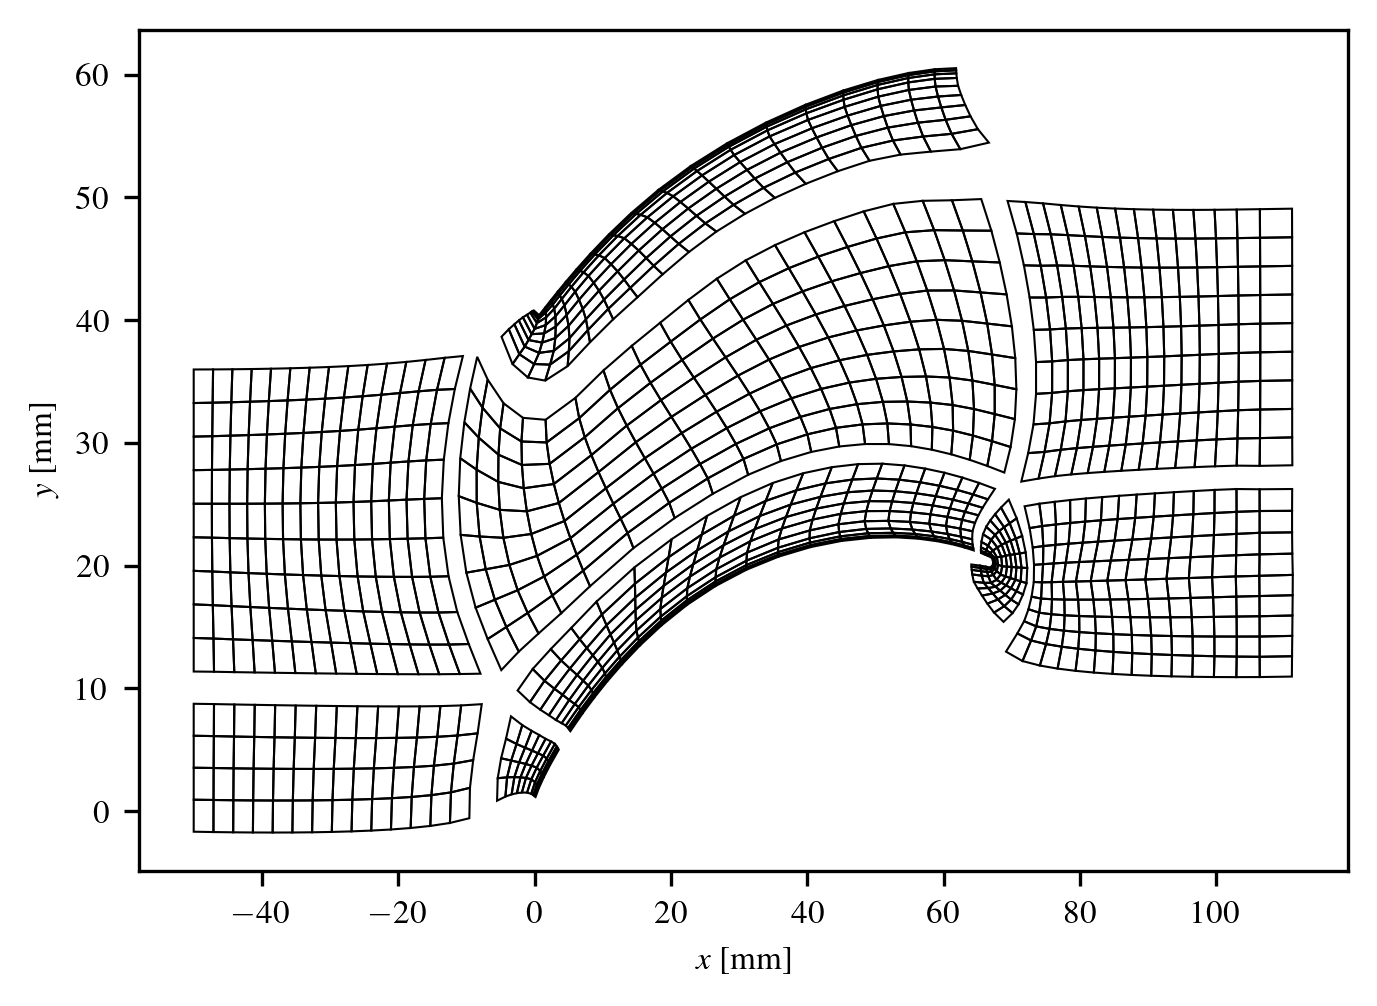

In [4]:
plot_grid(input_dir, True, n_bl=n_block, every=5, figsize=figsize)

The sensors coordinates are also extracted for each block

In [5]:
sensor = {}
for bl in range(1, n_block + 1):
    sensor[bl] = []
    nb_pt = block_info[f"block_{bl}"]["nb_points"]
    nb_li = block_info[f"block_{bl}"]["nb_lines"]
    if nb_pt > 0:
        for pt in range(1, nb_pt + 1):
            xs = block_info[f"block_{bl}"][f"point_{pt}"]["nx1"]
            ys = block_info[f"block_{bl}"][f"point_{pt}"]["ny1"]
            sensor[bl].append([xs, ys])
            print(f"point in block {bl} at indexes {xs, ys}")
    if nb_li > 0:
        for li in range(1, nb_li + 1):
            xs = block_info[f"block_{bl}"][f"line_{li}"]["nx1"]
            ys = block_info[f"block_{bl}"][f"line_{li}"]["ny1"]
            sensor[bl].append([xs, ys])
            print(f"line in block {bl} at indexes {xs, ys}")

line in block 1 at indexes (30, 1)
line in block 1 at indexes (1, 1)
line in block 7 at indexes (20, 30)
line in block 8 at indexes (1, 1)
line in block 8 at indexes (30, 1)


Statistics dictionary are created and filled with each block's data

In [6]:
stats1 = {}
stats2 = {}
for bl in range(1, n_block + 1):
    nx, ny = block_info[f"block_{bl}"]["nx"], block_info[f"block_{bl}"]["ny"]
    stats1[bl] = read_stats(os.path.join(input_dir, f"stats1_bl{bl}.bin"), nx, ny)
    stats2[bl] = read_stats(os.path.join(input_dir, f"stats2_bl{bl}.bin"), nx, ny)

Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...
Reading stats...


At that point, any statistical field can be plotted, e.g. the Mach

/tmp/ipykernel_552066/3203892128.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x, y, stats2[bl][var], vmin=vmin, vmax=vmax)


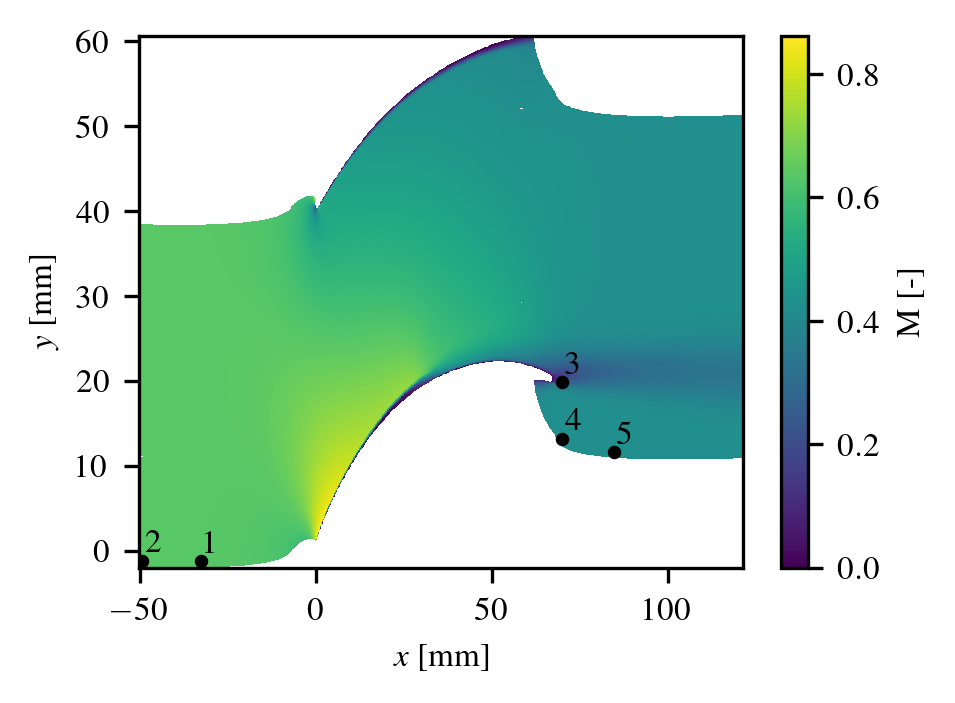

In [7]:
var = "M"

vmins, vmaxs = [], []
for bl in range(1, n_block + 1):
    vmins.append(stats2[bl][var].min())
    vmaxs.append(stats2[bl][var].max())  
vmin, vmax = min(vmins), max(vmaxs)

# fig, ax = plt.subplots(figsize=(5.2, 3.64))
fig, ax = plt.subplots(figsize=(3.25, 2.3))
ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')

for bl in range(1, n_block + 1):
    x = data[bl]['x']
    y = data[bl]['y']
    plt.pcolormesh(x, y, stats2[bl][var], vmin=vmin, vmax=vmax)

s_id = 1
epsilon = 1.
for bl in range(1, n_block + 1):
    for x_id, y_id in sensor[bl]:
        ax.scatter(data[bl]['x'][x_id, y_id], data[bl]['y'][x_id, y_id], marker="o", s=5, c="k")
        xy =(data[bl]['x'][x_id, y_id] + epsilon, data[bl]['y'][x_id, y_id] + epsilon)
        ax.annotate(f"{s_id}", xy=xy)
        s_id += 1
    
plt.colorbar(label=f'{var} [-]')
# fig.savefig(os.path.join(f"crit_{var}"), bbox_inches='tight')

#### 2. Total pressure, measurement planes and mixed out loss

The additional input variables are:
* `in_blocks` the inlet mesh blocks
* `out_blocks` the outlet mesh blocks
* `x1` and `x2` the measurement planes coordinates /x (mm)
* `pitch` the cascade pitch (mm)

In [8]:
in_blocks = [1, 2]
out_blocks = [8, 9]

x1 = -20.108296
x2 = 87.25188
pitch = 40.39

The total Pressure field is first computed

In [9]:
pres_tot = {bl:[] for bl in range(1, n_block + 1)}

for bl in range(1, n_block + 1):
    cp = stats2[bl]['cp']
    cv = stats2[bl]['cv']
    gamma = cp / cv
    Mach = stats2[bl]['M']
    pres = stats1[bl]['p']
    pres_tot[bl] = pres * (1 + (gamma - 1) / 2 * Mach**2)**(gamma / (gamma - 1))

The min/max values across all blocks are computed and the field as well as the sensors are plotted

**Note**: the grid can be displayed by adding the following options to the `plt.pcolormesh` command: `edgecolor="k", lw=0.1`.

/tmp/ipykernel_552066/515554220.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x, y, pres_tot[bl], vmin=vmin, vmax=vmax)


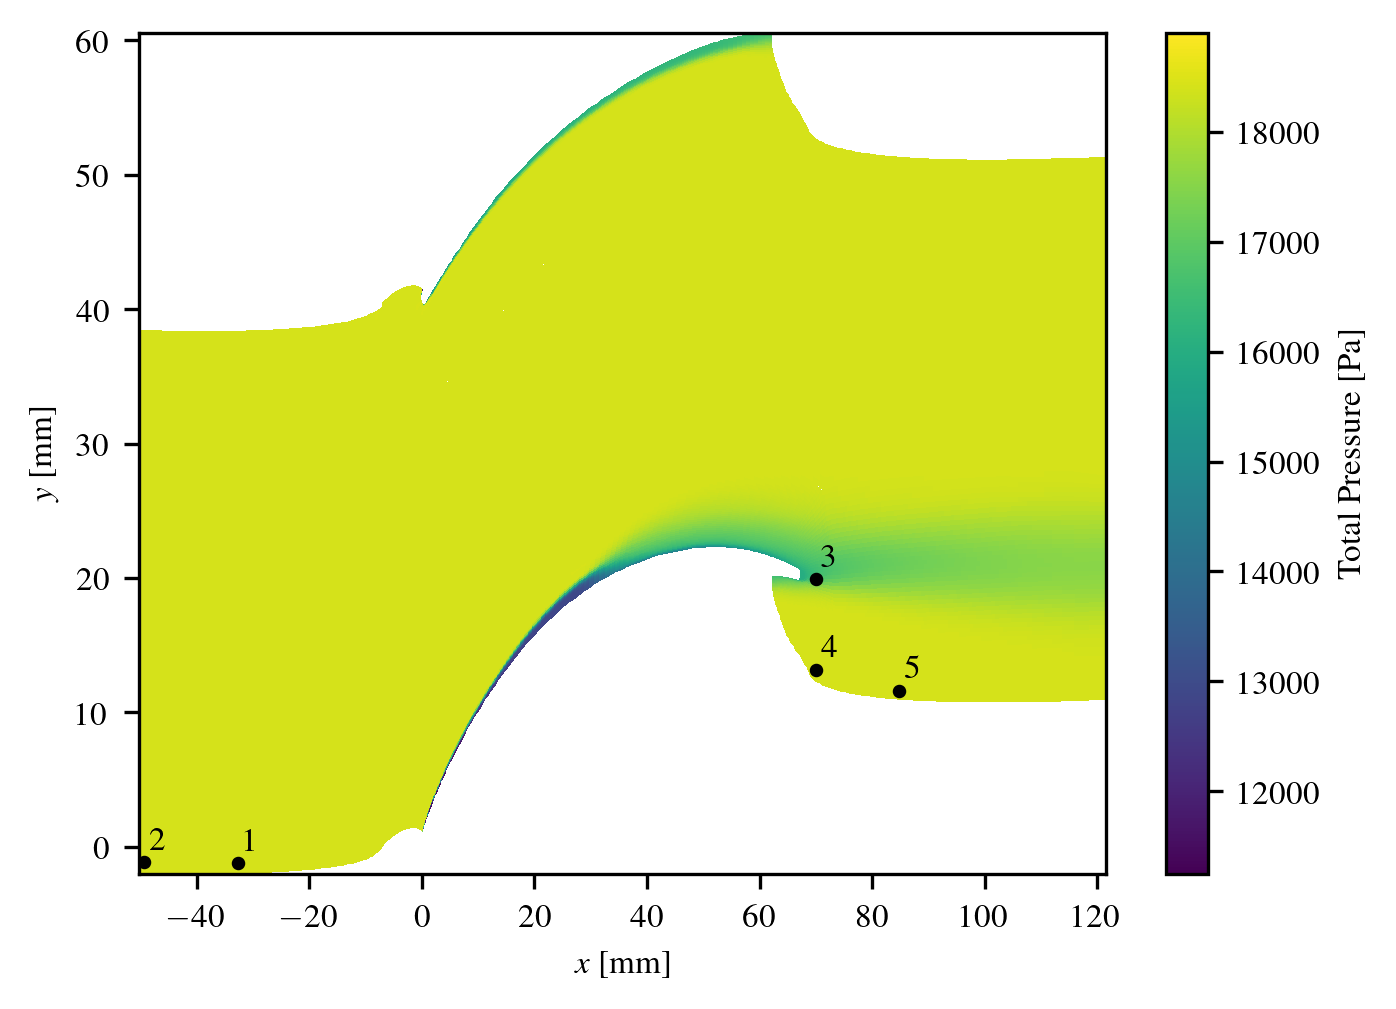

In [10]:
vmins, vmaxs = [], []
for bl in range(1, n_block + 1):
    vmins.append(pres_tot[bl].min())
    vmaxs.append(pres_tot[bl].max())  
vmin, vmax = min(vmins), max(vmaxs)

fig, ax = plt.subplots(figsize=figsize)
ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')

for bl in range(1, n_block + 1):
    x = data[bl]['x']
    y = data[bl]['y']
    plt.pcolormesh(x, y, pres_tot[bl], vmin=vmin, vmax=vmax)

s_id = 1
epsilon = 1.
for bl in range(1, n_block + 1):
    for x_id, y_id in sensor[bl]:
        ax.scatter(data[bl]['x'][x_id, y_id], data[bl]['y'][x_id, y_id], marker="o", s=5, c="k")
        xy =(data[bl]['x'][x_id, y_id] + epsilon, data[bl]['y'][x_id, y_id] + epsilon)
        ax.annotate(f"{s_id}", xy=xy)
        s_id += 1
    
plt.colorbar(label='Total Pressure [Pa]')

The coordinates and data are then merged at the inlet (`in_data`) and outlet (`out_data`)

In [11]:
# union of data
in_data = {}
for bl in in_blocks:
    in_data[bl] = data[bl] | stats1[bl] | stats2[bl]

out_data = {}
for bl in out_blocks:
    out_data[bl] = data[bl] | stats1[bl] | stats2[bl]

The limits along the y axis of both measurement planes are computed 

In [12]:
# find y corresponding to x1
x0 = in_data[in_blocks[0]]["x"]
closest_index = np.argmin(abs(x0[:, 0] - x1))
y1 = in_data[in_blocks[0]]["y"][closest_index, :].min()
y2 = y1 + pitch
# compute interpolation axis
y_in = np.linspace(y1, y2, 1000)
# build inlet_lims
inlet_lims = [x1, y1, x1, y2]
print(f"inlet_lims: {inlet_lims}")

inlet_lims: [-20.108296, -1.45296156498063, -20.108296, 38.93703843501937]


In [13]:
# find y corresponding to x1
x0 = out_data[out_blocks[0]]["x"]
closest_index = np.argmin(abs(x0[:, 0] - x2))
y1 = out_data[out_blocks[0]]["y"][closest_index, :].min()
y2 = y1 + pitch
# compute interpolation axis
y_out = np.linspace(y1, y2, 1000)
outlet_lims = [x2, y1, x2, y2]
print(f"outlet_lims: {outlet_lims}")

outlet_lims: [87.25188, 11.1099685537957, 87.25188, 51.499968553795696]


The measurement planes are finally plotted

/tmp/ipykernel_552066/1552730816.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(x, y, pres_tot[bl], vmin=vmin, vmax=vmax)


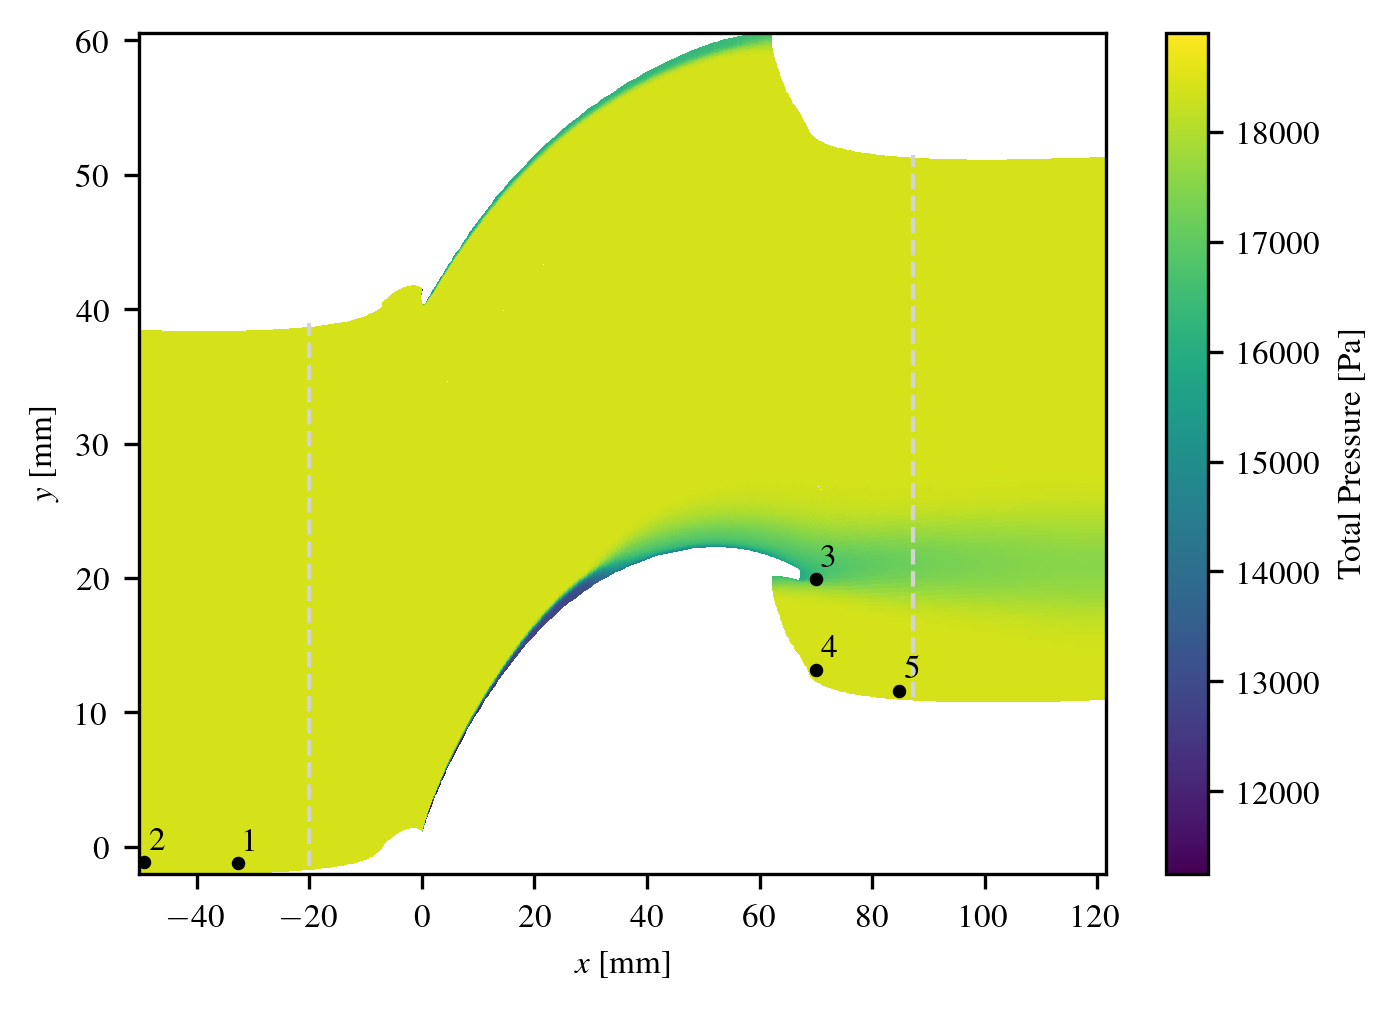

In [14]:
vmins, vmaxs = [], []
for bl in range(1, n_block + 1):
    vmins.append(pres_tot[bl].min())
    vmaxs.append(pres_tot[bl].max())  
vmin, vmax = min(vmins), max(vmaxs)

fig, ax = plt.subplots(figsize=figsize)
ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')

for bl in range(1, n_block + 1):
    x = data[bl]['x']
    y = data[bl]['y']
    plt.pcolormesh(x, y, pres_tot[bl], vmin=vmin, vmax=vmax)

s_id = 1
epsilon = 1.
for bl in range(1, n_block + 1):
    for x_id, y_id in sensor[bl]:
        ax.scatter(data[bl]['x'][x_id, y_id], data[bl]['y'][x_id, y_id], marker="o", s=5, c="k")
        xy =(data[bl]['x'][x_id, y_id] + epsilon, data[bl]['y'][x_id, y_id] + epsilon)
        ax.annotate(f"{s_id}", xy=xy)
        s_id += 1

plt.vlines(inlet_lims[0], inlet_lims[1], inlet_lims[-1], colors="lightgray", linestyles="dashed", lw=1)
plt.vlines(outlet_lims[0], outlet_lims[1], outlet_lims[-1], colors="lightgray", linestyles="dashed", lw=1)
  
plt.colorbar(label='Total Pressure [Pa]')

The data is interpolated along the measurement planes

In [15]:
data_inlet = {}
data_outlet = {}
for var in ["uu", "vv", "ww", "rhou", "rhov", "rho*uu", "rho*uv", "rho*uw", "p", "T", "M", "cp", "cv"]:
    data_inlet[f"{var}_interp"] = line_interp(in_data, var, inlet_lims, in_blocks)
    data_outlet[f"{var}_interp"] = line_interp(out_data, var, outlet_lims, out_blocks)

The mixed out loss coefficient is computed

In [16]:
# add gam and R entries as required by mixed_out
data_inlet["gam"] = np.nanmean(data_inlet["cp_interp"] / data_inlet["cv_interp"])
data_inlet["R"] = np.nanmean(data_inlet["cp_interp"] - data_inlet["cv_interp"])
data_outlet["gam"] = data_inlet["gam"]
data_outlet["R"] = data_inlet["R"]
# compute inlet/outlet mixed out states
inlet_mixed_out_state = mixed_out(data_inlet)
outlet_mixed_out_state = mixed_out(data_outlet)
# compute mixed out loss
mo_loss = (inlet_mixed_out_state["p0_bar"] - outlet_mixed_out_state["p0_bar"]) / (inlet_mixed_out_state["p0_bar"] - inlet_mixed_out_state["p_bar"])
print(f"mixed out loss: {mo_loss}")

mixed out loss: 0.031050196987993092


#### 3. Loss coefficient and isentropic Mach distributions

The additional input variables are:
* `path_to_loss` the path to the loss measurements
* `path_to_mis` the path to the isentropic Mach measurements
* `wall_blocks` the list of blocks encompassing the geometry walls.

In [17]:
path_to_loss = "cascade_loss.dat"
path_to_mis = "cascade_mis.dat"
wall_blocks = [3, 4, 7, 6]

The loss coefficient is computed similarly to the way done in WOLF i.e. by ponderating the pressure by the mass flow rate

**Note**: NaNs are automatically handled in `mixed_out` but they need to be taken care of explicitely below.

In [18]:
in_idx =  np.argwhere(~np.isnan(data_inlet["rhou_interp"]))
q1 = np.sum(data_inlet["rhou_interp"][in_idx])
P1 = np.sum(data_inlet["rhou_interp"][in_idx] * data_inlet["p_interp"][in_idx]) / q1
gamma = np.mean(data_inlet["cp_interp"][in_idx] / data_inlet["cv_interp"][in_idx])
print(f"gamma: {gamma}")
P01 = np.sum(data_inlet["p_interp"][in_idx] * (1 + (gamma - 1 ) / 2 * data_inlet["M_interp"][in_idx]**2)**(gamma / (gamma - 1)) * data_inlet["rhou_interp"][in_idx]) / q1
print(f"P1: {P1} (Pa)")
print(f"P01: {P01} (Pa)")

gamma: 1.4000000000002333
P1: 14018.927939430454 (Pa)
P01: 18416.178646204648 (Pa)


In [19]:
out_idx =  np.argwhere(~np.isnan(data_outlet["rhou_interp"]))
q2 = np.sum(data_outlet["rhou_interp"][out_idx])
P2 = np.sum(data_outlet["rhou_interp"][out_idx] * data_outlet["p_interp"][out_idx]) / q2
gamma = np.mean(data_outlet["cp_interp"][out_idx] / data_outlet["cv_interp"][out_idx])
print(f"gamma: {gamma}")
P02 = np.sum(data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1)) * data_outlet["rhou_interp"][out_idx]) / q2
print(f"P2: {P2} (Pa)")
print(f"P02: {P02} (Pa)")

gamma: 1.4000000000002333
P2: 16236.804138754862 (Pa)
P02: 18293.91207146012 (Pa)


In [20]:
print(f"Loss coefficient w: {(P01 - P02) / (P01 - P1)}")

Loss coefficient w: 0.027805231699927872


Text(0, 0.5, '$w$ [-]')

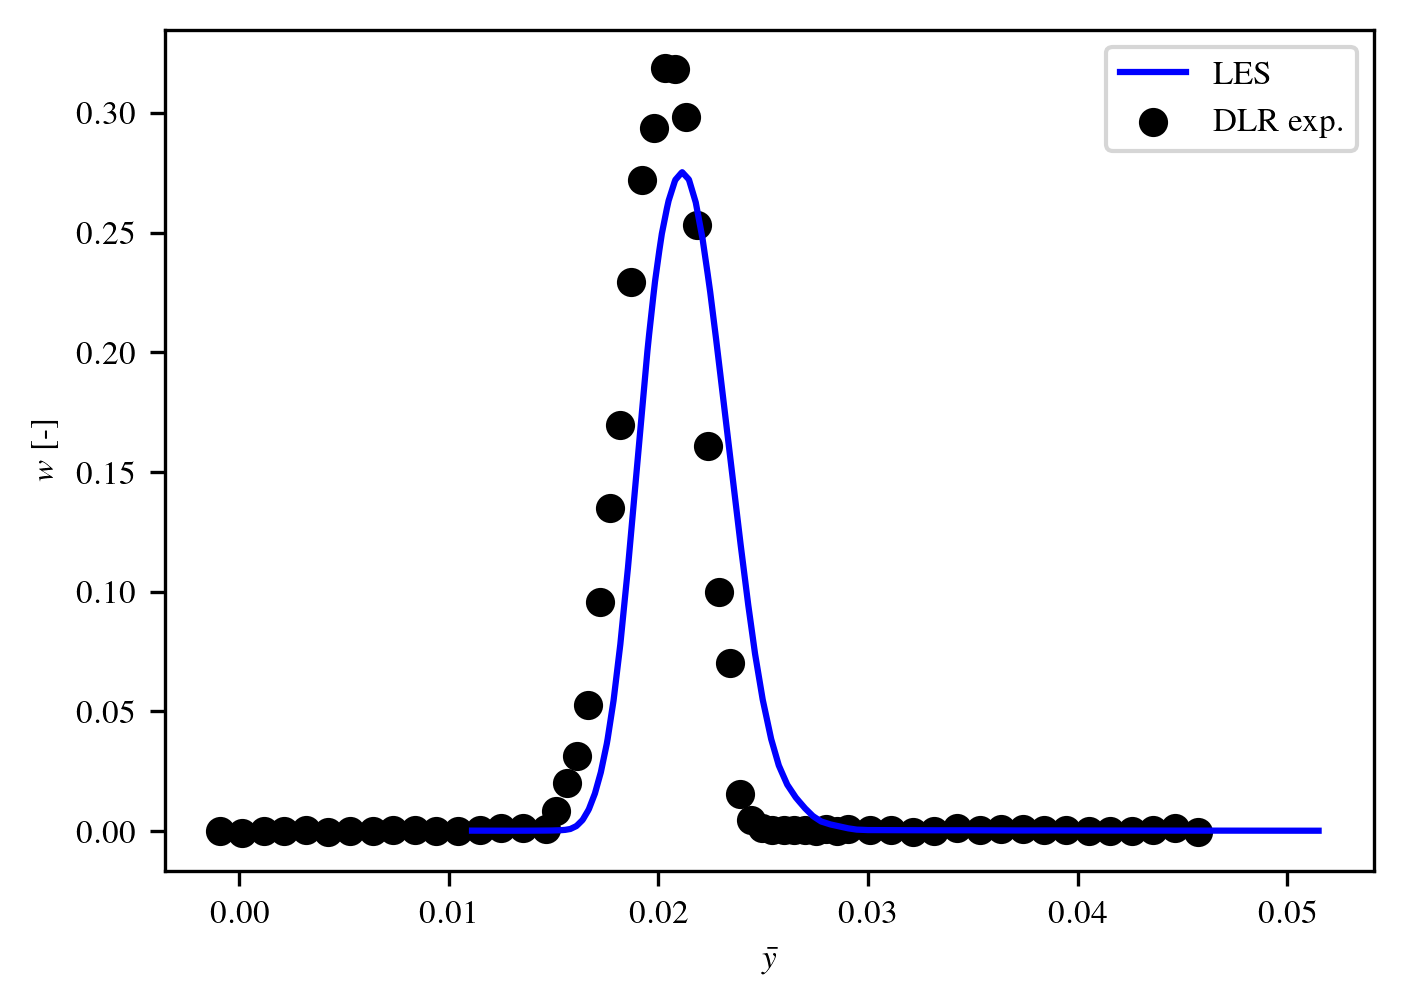

In [21]:
loss = (P01 - data_outlet["p_interp"][out_idx] * (1 + (gamma - 1 ) / 2 * data_outlet["M_interp"][out_idx]**2)**(gamma / (gamma - 1))) / (P01 - P1)
exp_loss = np.loadtxt(path_to_loss, skiprows=1)
delta= 0.0225

fig, ax = plt.subplots(figsize=figsize)
ax.plot(y_out[out_idx] / 1000, loss, color="blue", label="LES")
ax.scatter(exp_loss[:, 0] * 0.04039 + delta, exp_loss[:, 1], color="k", label="DLR exp.")
ax.legend()
ax.set_xlabel("$\\bar{y}$")
ax.set_ylabel("$w$ [-]")

The loss data is saved

In [22]:
outfile = f"loss_{output_key}.csv"
loss_df = pd.DataFrame(np.column_stack([y_out[out_idx] / 1000, loss]), columns=["y", "loss"])
# loss_df.to_csv(outfile, index=False)

The data is extracted along the wall

In [23]:
pres_wall_list = []
x_list = []
y_list = []

for bl in wall_blocks:
    new_pres_value = stats1[bl]['p'][:, 0]
    pres_wall_list.append(new_pres_value)
    
    new_x_value = data[bl]['x'][:, 0]
    x_list.append(new_x_value)

    new_y_value = data[bl]['y'][:, 0]
    y_list.append(new_y_value)

    
pres_wall = np.concatenate(pres_wall_list)
x_wall = np.concatenate(x_list) / 1000.
y_wall = np.concatenate(y_list) / 1000.
# x_tilde = np.cos(np.arctan(y_wall / x_wall) - (106.04 - 90) / 180 * np.pi) * np.sqrt(x_wall**2 + y_wall**2)

The isentropic Mach is computed

In [24]:
Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)

/tmp/ipykernel_552066/3819399028.py:1: RuntimeWarning: invalid value encountered in sqrt
  Mach_is = np.sqrt(((P01 / pres_wall)**((gamma - 1) / gamma) - 1) * 5)


Text(0, 0.5, '$Mis$ [-]')

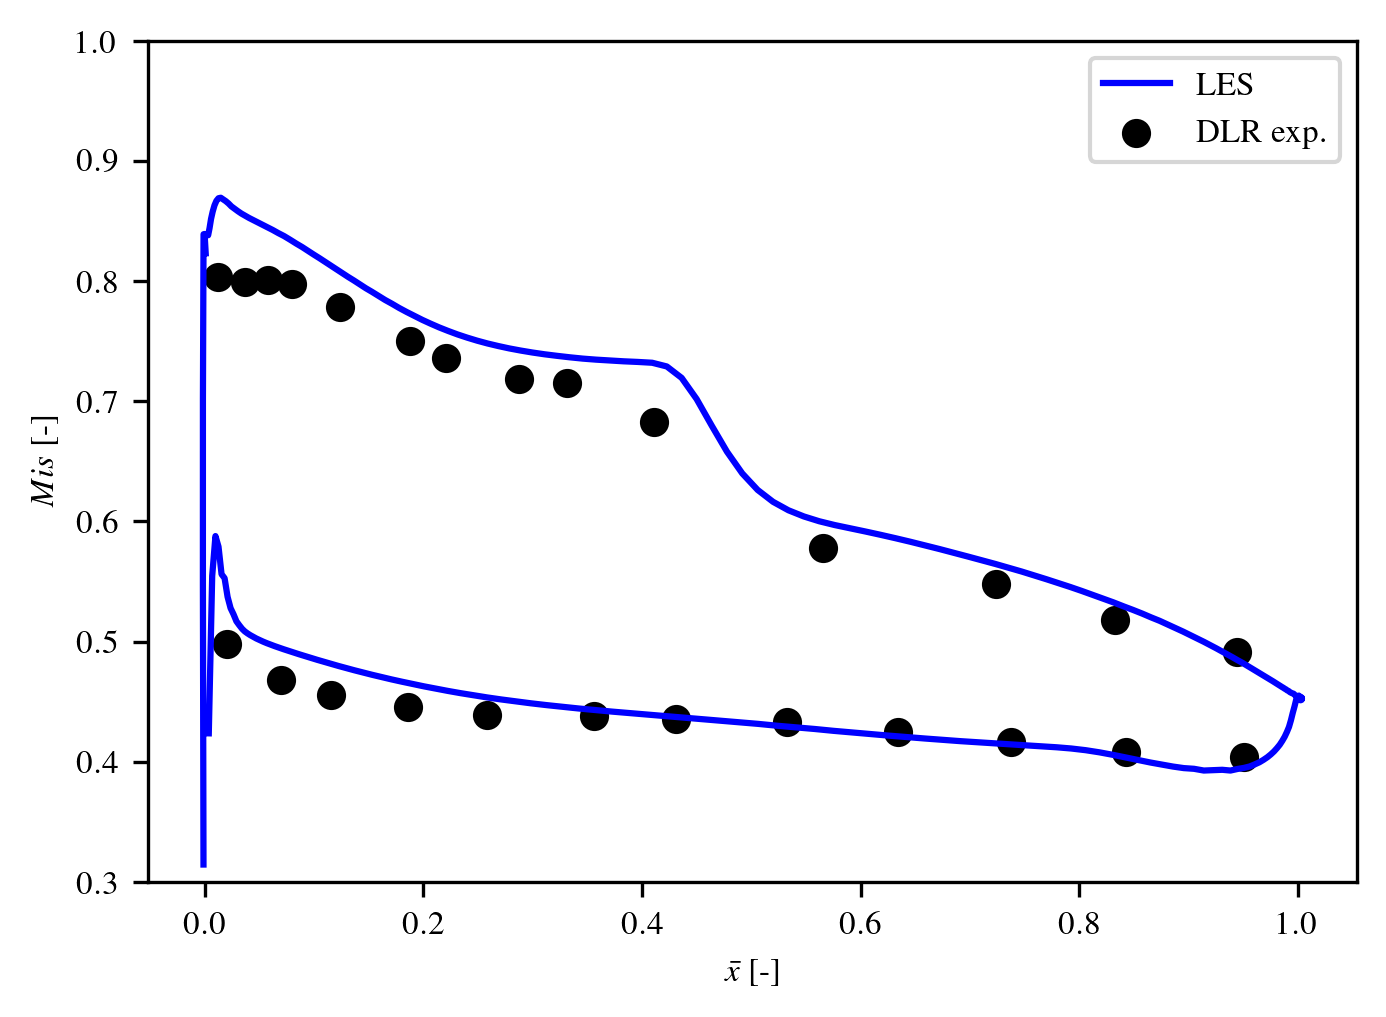

In [25]:
exp_mis = np.loadtxt(path_to_mis, skiprows=1)

fig, ax = plt.subplots(figsize=figsize)
ax.plot(x_wall / 0.067, Mach_is, color="blue", label="LES")
ax.scatter(exp_mis[:, 0] / 0.067, exp_mis[:, 1], color="k", label="DLR exp.")
ax.legend()
ax.set_ylim(0.3, 1.)
ax.set_xlabel('$\\bar{x}$ [-]')
ax.set_ylabel('$Mis$ [-]')

The isentropic Mach data is saved

In [26]:
outfile = f"mis_{output_key}.csv"
mis_df = pd.DataFrame(np.column_stack([x_wall, y_wall, x_wall / 0.067, Mach_is]), columns=["x", "y", "x/cax", "mis"])
# mis_df.to_csv(outfile, index=False)

#### 4. Outflow/inflow angles

In [27]:
u_mean = np.nanmean(data_outlet["rhou_interp"])
v_mean = np.nanmean(data_outlet["rhov_interp"])
print(f"Outflow angle: {np.atan(v_mean / u_mean) / np.pi * 180} deg.")

Outflow angle: 0.1368099687137699 deg.


In [28]:
u_mean = np.nanmean(data_inlet["rhou_interp"])
v_mean = np.nanmean(data_inlet["rhov_interp"])
print(f"Inflow angle: {np.atan(v_mean / u_mean) / np.pi * 180} deg.")

Inflow angle: 43.002478609499974 deg.


In [29]:
angle = np.nanmean(np.arctan(data_outlet["rhov_interp"] / data_outlet["rhou_interp"]))
print(f"Outflow angle: {angle / np.pi * 180} deg.")

Outflow angle: 0.13114246026075158 deg.


Paraview stats (extra step for paper)

In [ ]:
from musicaa_utils import write_para
para_dir = "ADP_stats_para"
os.makedirs(os.path.join(input_dir, para_dir, "par_planes"))
write_para(input_dir, para_dir, plane_nb=-1, var_names="", stats=True)